# **1. Perkenalan Dataset**


Dataset ini berasal dari Behavioral Risk Factor Surveillance System (BRFSS) 2015 yang dikumpulkan oleh CDC (Centers for Disease Control and Prevention) yaitu lembaga kesehatan resmi pemerintah Amerika Serikat.

Dataset `diabetes_binary_health_indicators_BRFSS2015.csv` berisi:
- 253.680 responden
- 21 fitur kesehatan dan gaya hidup
- Target biner `Diabetes_binary` (0 = tidak diabetes, 1 = prediabetes/diabetes)

Tujuan: Membangun model prediksi risiko diabetes berdasarkan indikator kesehatan.

Sumber: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset


# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('/content/diabetes_binary_health_indicators_BRFSS2015.csv')

print("Shape dataset:", df.shape)
print("\n5 baris pertama:")
df.head()

Shape dataset: (253680, 22)

5 baris pertama:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# 4.1 Informasi Umum Dataset
print("="*50)
print("INFORMASI DATASET")
print("="*50)
df.info()

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-n

In [4]:
# 4.2 Statistik Deskriptif
print("="*50)
print("STATISTIK DESKRIPTIF")
print("="*50)
df.describe()

STATISTIK DESKRIPTIF


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [5]:
# 4.3 Cek Missing Values dan Duplikat
print("="*50)
print("CEK MISSING VALUES")
print("="*50)
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

print("\n" + "="*50)
print("CEK DUPLIKAT")
print("="*50)
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

CEK MISSING VALUES
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Total missing values: 0

CEK DUPLIKAT
Jumlah baris duplikat: 24206


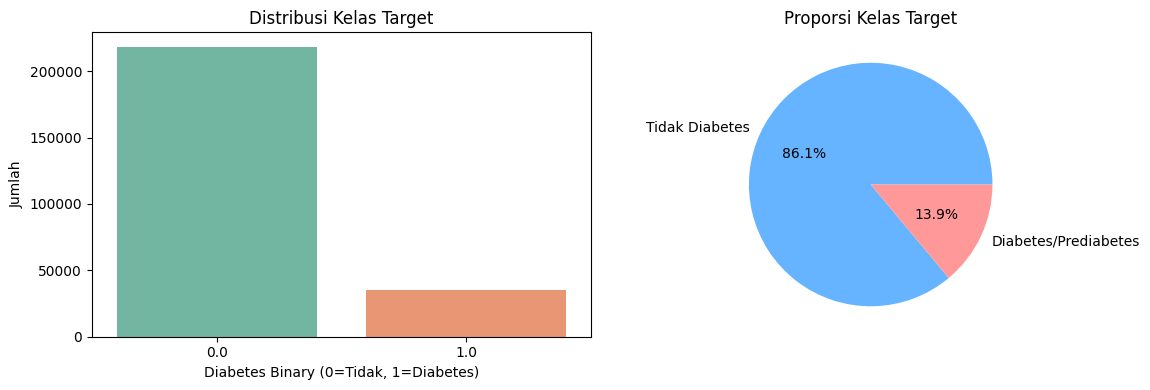


Distribusi target:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Proporsi target:
Diabetes_binary
0.0    0.861
1.0    0.139
Name: proportion, dtype: float64


In [6]:
# 4.4 Distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='Diabetes_binary', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Kelas Target')
axes[0].set_xlabel('Diabetes Binary (0=Tidak, 1=Diabetes)')
axes[0].set_ylabel('Jumlah')

# Pie chart
labels = ['Tidak Diabetes', 'Diabetes/Prediabetes']
sizes = df['Diabetes_binary'].value_counts()
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
axes[1].set_title('Proporsi Kelas Target')

plt.tight_layout()
plt.show()

print("\nDistribusi target:")
print(df['Diabetes_binary'].value_counts())
print("\nProporsi target:")
print(df['Diabetes_binary'].value_counts(normalize=True).round(3))

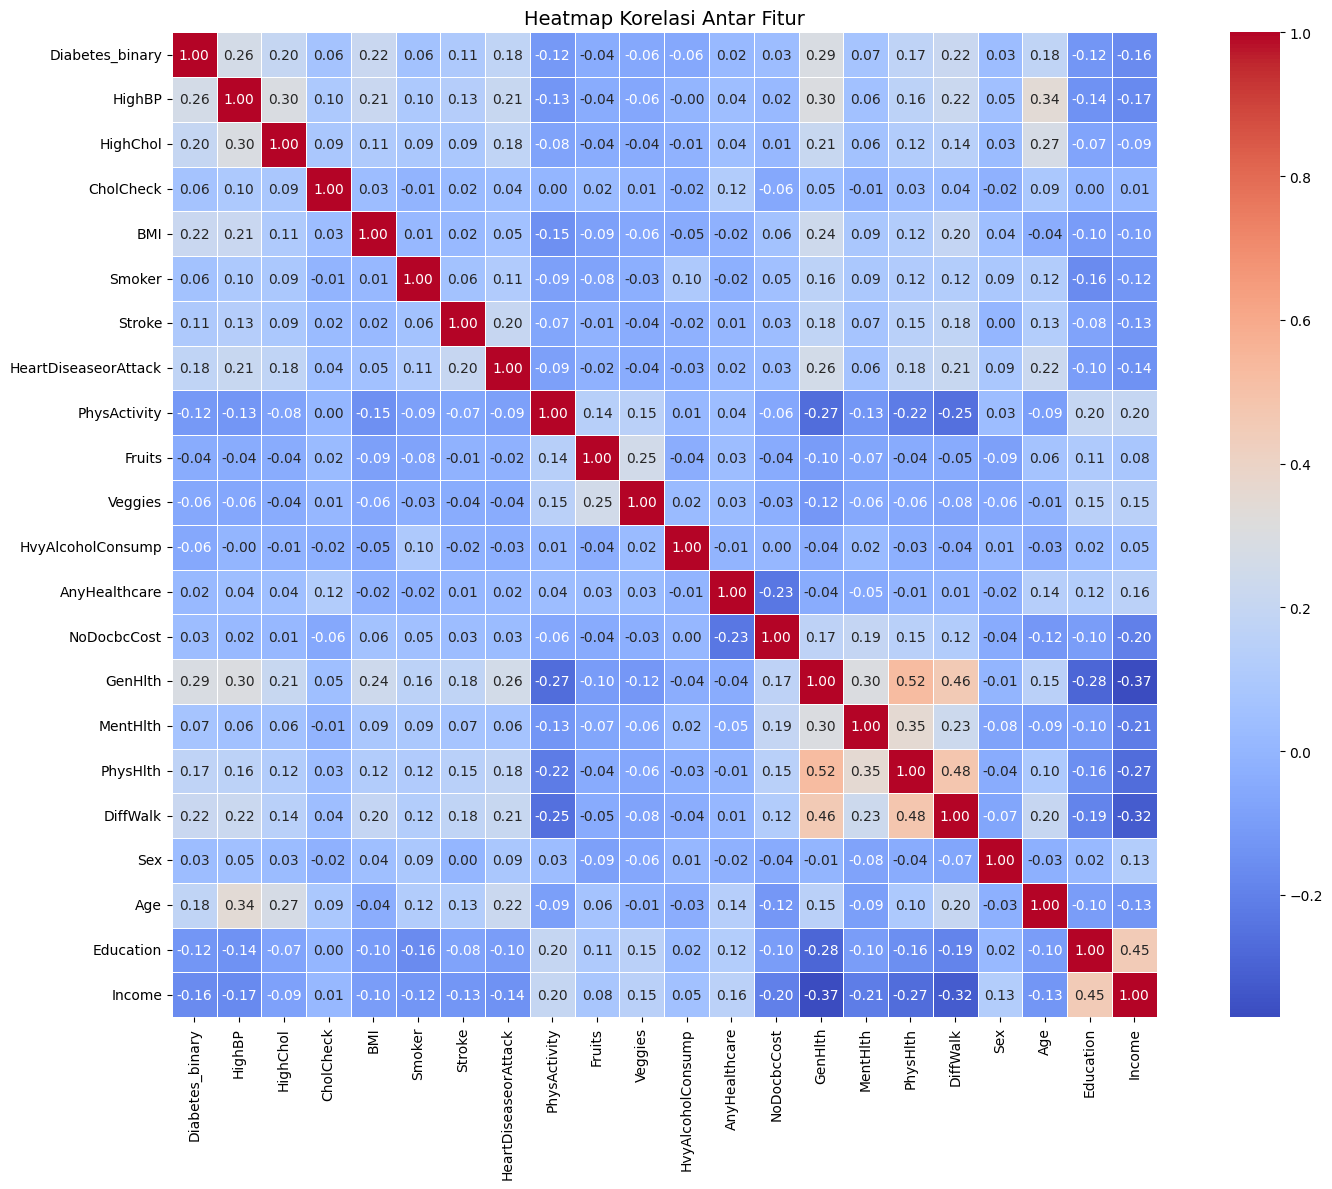

In [7]:
# 4.5 Heatmap Korelasi
plt.figure(figsize=(16, 12))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.tight_layout()
plt.show()

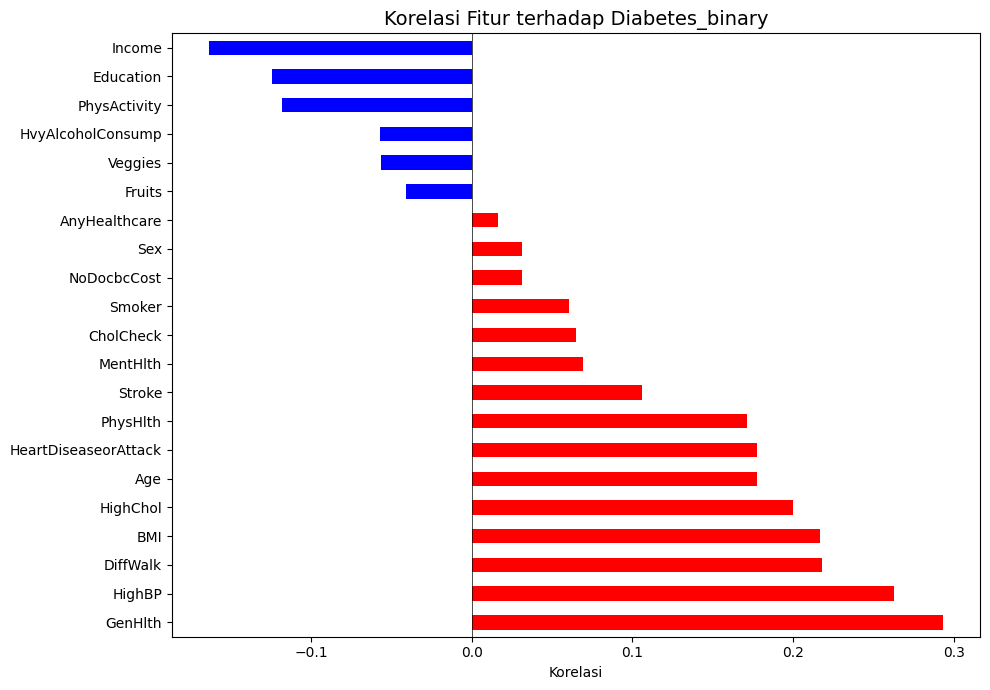


Fitur paling berkorelasi positif:
GenHlth     0.293569
HighBP      0.263129
DiffWalk    0.218344
BMI         0.216843
HighChol    0.200276
Name: Diabetes_binary, dtype: float64

Fitur paling berkorelasi negatif:
Veggies             -0.056584
HvyAlcoholConsump   -0.057056
PhysActivity        -0.118133
Education           -0.124456
Income              -0.163919
Name: Diabetes_binary, dtype: float64


In [8]:
# 4.6 Korelasi Fitur terhadap Target
corr_target = corr['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)

plt.figure(figsize=(10, 7))
corr_target.plot(kind='barh', color=['red' if x > 0 else 'blue' for x in corr_target])
plt.title('Korelasi Fitur terhadap Diabetes_binary', fontsize=14)
plt.xlabel('Korelasi')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nFitur paling berkorelasi positif:")
print(corr_target.head(5))
print("\nFitur paling berkorelasi negatif:")
print(corr_target.tail(5))

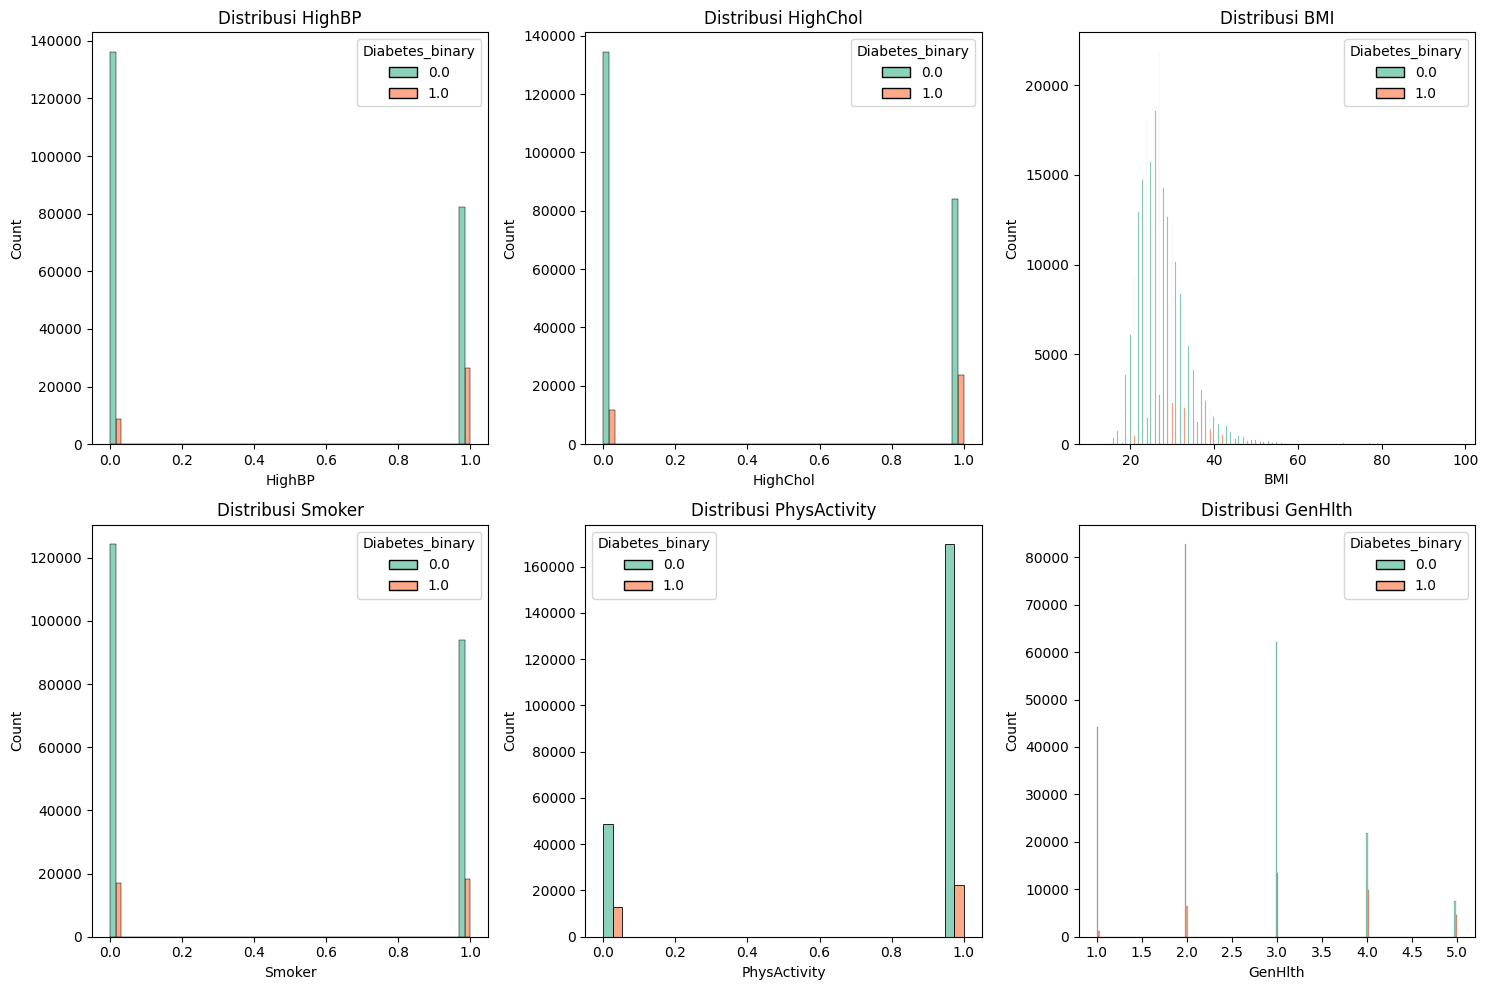

In [9]:
# 4.7 Distribusi Fitur Kunci berdasarkan Target
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
cols = ['HighBP', 'HighChol', 'BMI', 'Smoker', 'PhysActivity', 'GenHlth']

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, hue='Diabetes_binary',
                multiple='dodge', ax=axes[i//3, i%3], palette='Set2')
    axes[i//3, i%3].set_title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

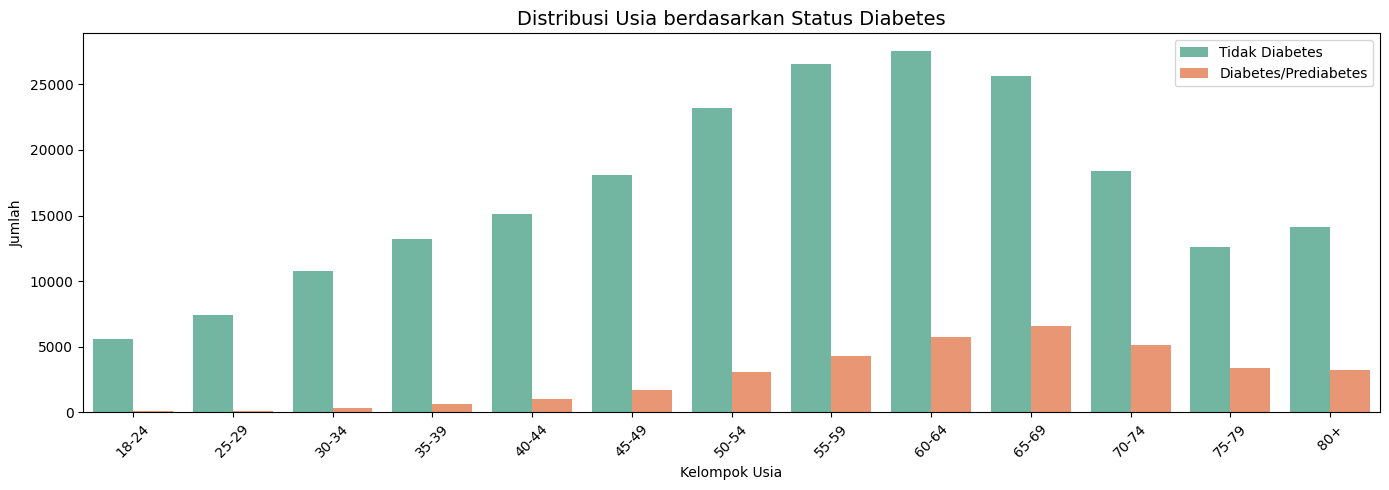

In [12]:
# 4.8 Distribusi Usia berdasarkan Status Diabetes
age_labels = {
    1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39',
    5: '40-44', 6: '45-49', 7: '50-54', 8: '55-59',
    9: '60-64', 10: '65-69', 11: '70-74', 12: '75-79',
    13: '80+'
}

# Buat kolom baru dengan label usia
df_plot = df.copy()
df_plot['Age_Label'] = df_plot['Age'].map(age_labels)

plt.figure(figsize=(14, 5))
sns.countplot(
    x='Age_Label',
    hue='Diabetes_binary',
    data=df_plot,
    order=age_labels.values(),
    palette='Set2'
)
plt.title('Distribusi Usia berdasarkan Status Diabetes', fontsize=14)
plt.xlabel('Kelompok Usia')
plt.ylabel('Jumlah')
plt.legend(['Tidak Diabetes', 'Diabetes/Prediabetes'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

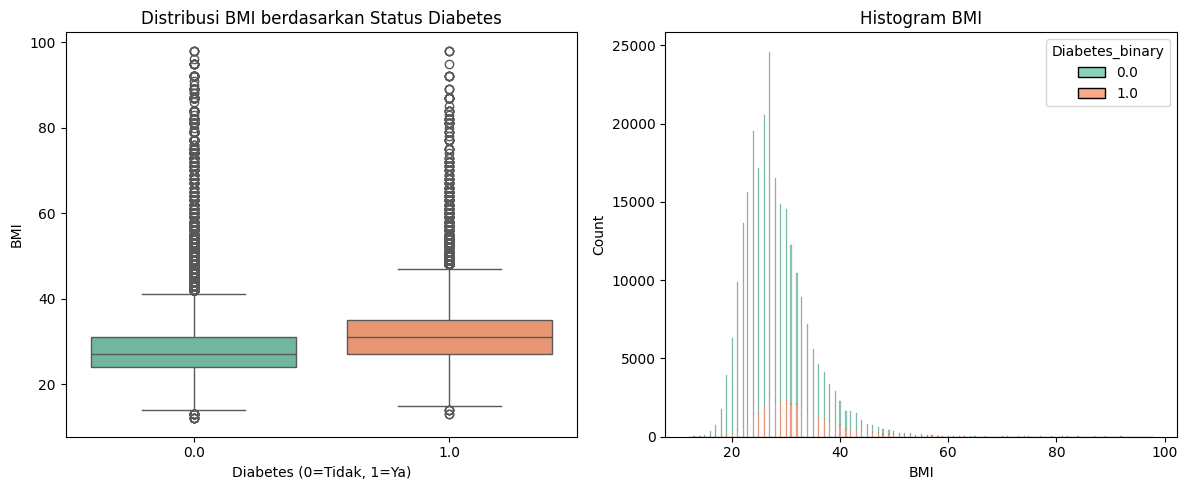


STATISTIK BMI — Tidak Diabetes (0)
Minimum    : 12.00
Q1 (25%)   : 24.00
Median     : 27.00
Q3 (75%)   : 31.00
Maksimum   : 98.00
IQR        : 7.00
Batas bawah whisker : 13.50
Batas atas whisker  : 41.50
Jumlah outlier      : 6480 (2.97%)
Rata-rata  : 27.81
Std dev    : 6.29

STATISTIK BMI — Diabetes/Prediabetes (1)
Minimum    : 13.00
Q1 (25%)   : 27.00
Median     : 31.00
Q3 (75%)   : 35.00
Maksimum   : 98.00
IQR        : 8.00
Batas bawah whisker : 15.00
Batas atas whisker  : 47.00
Jumlah outlier      : 1203 (3.40%)
Rata-rata  : 31.94
Std dev    : 7.36

PERBANDINGAN
Selisih median BMI  : 4.00
Selisih rata-rata   : 4.14
→ Orang DIABETES memiliki BMI lebih TINGGI
  sebesar 4.00 poin dari yang tidak diabetes
→ Variasi BMI pada kelompok diabetes lebih BESAR
  (data lebih menyebar)


In [14]:
# 4.9 Deteksi Outlier pada BMI
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot BMI
sns.boxplot(x='Diabetes_binary', y='BMI', data=df,
            ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi BMI berdasarkan Status Diabetes')
axes[0].set_xlabel('Diabetes (0=Tidak, 1=Ya)')
axes[0].set_ylabel('BMI')

# Histogram BMI
sns.histplot(data=df, x='BMI', hue='Diabetes_binary',
             multiple='stack', ax=axes[1], palette='Set2')
axes[1].set_title('Histogram BMI')

plt.tight_layout()
plt.show()

# ============================================
# TEKS HASIL OTOMATIS
# ============================================
bmi_tidak = df[df['Diabetes_binary'] == 0]['BMI']
bmi_diabetes = df[df['Diabetes_binary'] == 1]['BMI']

# Hitung statistik
def hitung_boxplot_stats(data, label):
    Q1 = data.quantile(0.25)
    Q2 = data.quantile(0.50)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = data[(data < lower) | (data > upper)].shape[0]
    outlier_pct = (outlier_count / len(data)) * 100

    print(f"\n{'='*40}")
    print(f"STATISTIK BMI — {label}")
    print(f"{'='*40}")
    print(f"Minimum    : {data.min():.2f}")
    print(f"Q1 (25%)   : {Q1:.2f}")
    print(f"Median     : {Q2:.2f}")
    print(f"Q3 (75%)   : {Q3:.2f}")
    print(f"Maksimum   : {data.max():.2f}")
    print(f"IQR        : {IQR:.2f}")
    print(f"Batas bawah whisker : {lower:.2f}")
    print(f"Batas atas whisker  : {upper:.2f}")
    print(f"Jumlah outlier      : {outlier_count} ({outlier_pct:.2f}%)")
    print(f"Rata-rata  : {data.mean():.2f}")
    print(f"Std dev    : {data.std():.2f}")

hitung_boxplot_stats(bmi_tidak, "Tidak Diabetes (0)")
hitung_boxplot_stats(bmi_diabetes, "Diabetes/Prediabetes (1)")

# Perbandingan otomatis
print(f"\n{'='*40}")
print("PERBANDINGAN")
print(f"{'='*40}")
selisih_median = bmi_diabetes.median() - bmi_tidak.median()
selisih_mean = bmi_diabetes.mean() - bmi_tidak.mean()
print(f"Selisih median BMI  : {selisih_median:.2f}")
print(f"Selisih rata-rata   : {selisih_mean:.2f}")

if selisih_median > 0:
    print(f"→ Orang DIABETES memiliki BMI lebih TINGGI")
    print(f"  sebesar {selisih_median:.2f} poin dari yang tidak diabetes")
else:
    print(f"→ Orang TIDAK DIABETES memiliki BMI lebih TINGGI")

if bmi_diabetes.std() > bmi_tidak.std():
    print(f"→ Variasi BMI pada kelompok diabetes lebih BESAR")
    print(f"  (data lebih menyebar)")
else:
    print(f"→ Variasi BMI pada kelompok diabetes lebih KECIL")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [15]:
# 5.1 Menghapus Data Duplikat
print(f"Jumlah baris sebelum hapus duplikat: {df.shape[0]}")
df = df.drop_duplicates()
print(f"Jumlah baris setelah hapus duplikat: {df.shape[0]}")

Jumlah baris sebelum hapus duplikat: 253680
Jumlah baris setelah hapus duplikat: 229474


In [16]:
# 5.2 Menangani Missing Values
print("Missing values per kolom:")
print(df.isnull().sum())

# Dataset ini tidak ada missing values
# tapi tetap diterapkan sebagai best practice
df = df.dropna()
print(f"\nShape setelah handling missing values: {df.shape}")

Missing values per kolom:
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Shape setelah handling missing values: (229474, 22)


In [17]:
# 5.3 Deteksi dan Handling Outlier pada BMI
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = df[(df['BMI'] < lower) | (df['BMI'] > upper)].shape[0]
print(f"Q1 BMI: {Q1}")
print(f"Q3 BMI: {Q3}")
print(f"IQR BMI: {IQR}")
print(f"Batas bawah: {lower}")
print(f"Batas atas: {upper}")
print(f"Jumlah outlier BMI: {outlier_count}")

# Hapus outlier
df = df[(df['BMI'] >= lower) & (df['BMI'] <= upper)]
print(f"\nShape setelah hapus outlier: {df.shape}")

Q1 BMI: 24.0
Q3 BMI: 32.0
IQR BMI: 8.0
Batas bawah: 12.0
Batas atas: 44.0
Jumlah outlier BMI: 5638

Shape setelah hapus outlier: (223836, 22)


In [18]:
# 5.4 Memisahkan Fitur dan Target
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

print("Shape fitur (X):", X.shape)
print("Shape target (y):", y.shape)
print("\nKolom fitur:")
print(X.columns.tolist())

Shape fitur (X): (223836, 21)
Shape target (y): (223836,)

Kolom fitur:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [19]:
# 5.5 Standarisasi Fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Statistik setelah standarisasi:")
print(X_scaled.describe().round(3))

Statistik setelah standarisasi:
           HighBP    HighChol   CholCheck         BMI      Smoker      Stroke  \
count  223836.000  223836.000  223836.000  223836.000  223836.000  223836.000   
mean        0.000      -0.000      -0.000      -0.000      -0.000       0.000   
std         1.000       1.000       1.000       1.000       1.000       1.000   
min        -0.904      -0.888      -4.842      -2.971      -0.935      -0.216   
25%        -0.904      -0.888       0.207      -0.754      -0.935      -0.216   
50%        -0.904      -0.888       0.207      -0.199      -0.935      -0.216   
75%         1.107       1.127       0.207       0.540       1.069      -0.216   
max         1.107       1.127       0.207       2.942       1.069       4.626   

       HeartDiseaseorAttack  PhysActivity      Fruits     Veggies  ...  \
count            223836.000    223836.000  223836.000  223836.000  ...   
mean                  0.000        -0.000       0.000       0.000  ...   
std             

In [20]:
# 5.6 Split Data Train dan Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("="*50)
print("HASIL SPLIT DATA")
print("="*50)
print(f"Training set : {X_train.shape[0]} baris")
print(f"Test set     : {X_test.shape[0]} baris")
print(f"\nDistribusi target - Training:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribusi target - Test:")
print(y_test.value_counts(normalize=True).round(3))

HASIL SPLIT DATA
Training set : 179068 baris
Test set     : 44768 baris

Distribusi target - Training:
Diabetes_binary
0.0    0.852
1.0    0.148
Name: proportion, dtype: float64

Distribusi target - Test:
Diabetes_binary
0.0    0.852
1.0    0.148
Name: proportion, dtype: float64


In [22]:
# 5.7 Simpan Dataset yang Sudah Dipreprocess
X_train_save = X_train.copy()
X_train_save['Diabetes_binary'] = y_train.values

X_test_save = X_test.copy()
X_test_save['Diabetes_binary'] = y_test.values

X_train_save.to_csv('/content/diabetes_train.csv', index=False)
X_test_save.to_csv('/content/diabetes_test.csv', index=False)

print("Dataset preprocessing berhasil disimpan!")
print("- /content/diabetes_train.csv")
print("- /content/diabetes_test.csv")

Dataset preprocessing berhasil disimpan!
- /content/diabetes_train.csv
- /content/diabetes_test.csv
